In [3]:
#Standard operational package imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

#This function displays the splits of the tree
from sklearn.tree import plot_tree

from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#GridSearch
from sklearn.model_selection import GridSearchCV

In [4]:
sys.path.append('C:/Users/MSI Modern/Downloads/Google_Advanced_Data_Analytics_Professional/KevinVChin/6-The_Nuts_and_Bolts_of_Machine_Learning/4-Module/1-Additional_supervised_learning_techniques/Churn_Modelling.csv')

In [5]:
df_original= pd.read_csv('C:/Users/MSI Modern/Downloads/Google_Advanced_Data_Analytics_Professional/KevinVChin/6-The_Nuts_and_Bolts_of_Machine_Learning/4-Module/1-Additional_supervised_learning_techniques/Churn_Modelling.csv')
df_original.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
#Check class balance 
df_original['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [7]:
#Calculate the average balance of customers who churned 
avg_churned_bal= df_original[df_original['Exited']==1]['Balance'].mean()
avg_churned_bal

91108.53933726068

In [8]:
#Create new Df that drops RowNumber, CustomerId, Surname, Gender cols
churn_df= df_original.drop(['RowNumber', 'CustomerId', 'Surname', 'Gender'], axis=1)
churn_df.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0
2,502,France,42,8,159660.80,3,1,0,113931.57,1
3,699,France,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,43,2,125510.82,1,1,1,79084.10,0


In [9]:
#Dummy encode categorical var
churn_df= pd.get_dummies(churn_df, drop_first='True')
churn_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True


In [10]:
#Split data 
y= churn_df['Exited']

X= churn_df.copy()
X= X.drop('Exited', axis=1 )

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.25, stratify= y, random_state= 42)

In [11]:
#Instantiate the model 
decision_tree= DecisionTreeClassifier(random_state= 0)

#Fit the model to train the data
decision_tree.fit(X_train, y_train)

#Make prediction on the test data 
dt_pred= decision_tree.predict(X_test)

In [12]:
#Generate performance metrics
print('Accuracy:', '%.3f' % accuracy_score(y_test, dt_pred))
print('Precision:', '%.3f' % precision_score(y_test, dt_pred))
print('Recall:', '%.3f' % recall_score(y_test, dt_pred))
print('F1 Score:', '%.3f' % f1_score(y_test, dt_pred))

Accuracy: 0.790
Precision: 0.486
Recall: 0.503
F1 Score: 0.494


In [13]:
def conf_matrix_plot(model, x_data, y_data):
#'''
#Accepts as argument model object, X data(Test or validate), and y data(Test or validate)
#Returns a plot of confusion matrix for predictions on Y data
#'''

    model_pred= model.predict(x_data)
    cm= confusion_matrix(y_data, model_pred, labels= model.classes_)
    disp= ConfusionMatrixDisplay(confusion_matrix=cm, 
                            display_labels= model.classes_)

    disp.plot()
    plt.show()

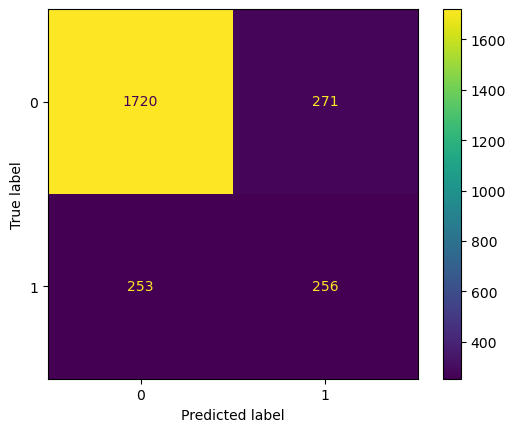

In [14]:
#Generate the confusion matrix

conf_matrix_plot(decision_tree, X_test, y_test)

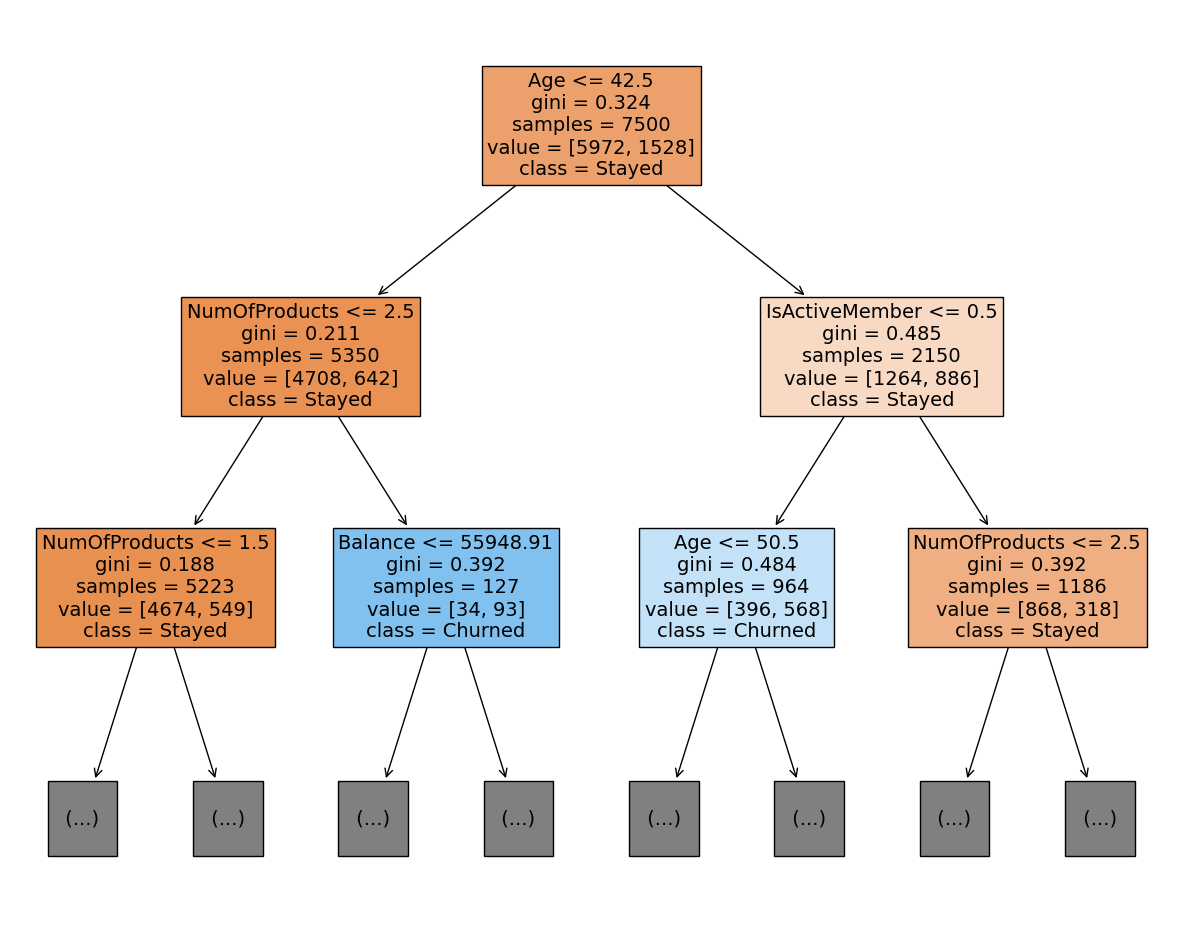

In [15]:
#Examine the split of the tree
#Plot the tree
plt.figure(figsize=(15, 12))
plot_tree(decision_tree, max_depth= 2, fontsize= 14, feature_names= X.columns, class_names= {0:'Stayed', 1:'Churned'}, filled= True);

#plt.show()

In [16]:
#Hyperparameters
#Parameters that can be set before the model is trained 

#Max Depth= How long a decision tree can get 
#Min sample leaf= Define the minimum number of samples for a leaf node(If not enough samples then the node will not split)
#GridSearch= Use to confirm that a model achieves its intended purpose by systematically checking every combination of hyperparameters to identify which set produces the best results, based on the selected metric

In [17]:
#Define a dictionary where the Key is the name of Hyper Parameter and the value is the list of num that will be tried as that Hyper Parameter

tree_para= {'max_depth':[4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 20, 30, 40, 50],
           'min_samples_leaf':[2, 5, 10, 20, 50]}

In [18]:
#While the Grid search is based on the F1 score, but still need to find out what other scores are

scoring= {'accuracy', 'precision', 'recall', 'f1'}

In [19]:
tuned_decision_tree= DecisionTreeClassifier(random_state= 42)

In [20]:
scoring = ['accuracy', 'precision', 'recall', 'f1_weighted'] #Assign it as a var, then call it in clf

clf= GridSearchCV(tuned_decision_tree, 
                  tree_para,
                  cv=5,
                  #refit= 'f1'
                  scoring=scoring, 
                  refit='f1_weighted') 

clf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 20, 30,
                                       40, 50],
                         'min_samples_leaf': [2, 5, 10, 20, 50]},
             refit='f1_weighted',
             scoring=['accuracy', 'precision', 'recall', 'f1_weighted'])

In [21]:
#Check if the Key 'mean_test_f1_weighted' appeared

print(clf.cv_results_.keys())

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_min_samples_leaf', 'params', 'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy', 'split3_test_accuracy', 'split4_test_accuracy', 'mean_test_accuracy', 'std_test_accuracy', 'rank_test_accuracy', 'split0_test_precision', 'split1_test_precision', 'split2_test_precision', 'split3_test_precision', 'split4_test_precision', 'mean_test_precision', 'std_test_precision', 'rank_test_precision', 'split0_test_recall', 'split1_test_recall', 'split2_test_recall', 'split3_test_recall', 'split4_test_recall', 'mean_test_recall', 'std_test_recall', 'rank_test_recall', 'split0_test_f1_weighted', 'split1_test_f1_weighted', 'split2_test_f1_weighted', 'split3_test_f1_weighted', 'split4_test_f1_weighted', 'mean_test_f1_weighted', 'std_test_f1_weighted', 'rank_test_f1_weighted'])


In [22]:
clf.best_estimator_

DecisionTreeClassifier(max_depth=7, min_samples_leaf=20, random_state=42)

In [23]:
print('Best Avg. Validation Score: ', '%.4f' % clf.best_score_)

Best Avg. Validation Score:  0.8418


In [24]:
results= pd.DataFrame(columns= ['Model', 'F1', 'Recall', 'Precision', 'Accuracy'])
                      
def make_results(model_name, model_object):
    '''
    Accepts as arguments a model name (your choice - string) and
    a fit GridSearchCV model object.
  
    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean F1 score across all validation folds.  
    '''

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(mean f1 score)
    best_estimator_results = cv_results.iloc[cv_results['mean_test_f1_weighted'].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1_weighted
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Create table of results
    table = pd.DataFrame()
    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                          'F1': [f1],
                          'Recall': [recall],
                          'Precision': [precision],
                          'Accuracy': [accuracy]
                         }
                        )
  
    return table

In [25]:
# Call the function on our model
result_table = make_results("Tuned Decision Tree", clf)

In [26]:
# Save table as csv
result_table.to_csv("Results.csv")

In [27]:
# View the results
result_table

,Model,F1,Recall,Precision,Accuracy
0,Tuned Decision Tree,0.841815,0.450935,0.742597,0.856
